# ISIC2019 Full Fixed Pipeline

This notebook merges the preprocessing flow from the first notebook with the clean three-way dataset export flow from the second notebook.

It produces:
- `SOTA_dataset/train/<8 class folders>/`
- `SOTA_dataset/val/<8 class folders>/`
- `SOTA_dataset/test/<8 class folders>/`
- `train.csv`, `val.csv`, `test.csv`, `manifest.csv`
- `dataset_summary.json`
- `SOTA_dataset.zip`

It also shows an example of:
`Original → Processed → Difference Map`

In [7]:
# Install dependencies if needed
!pip -q install pandas scikit-learn opencv-python matplotlib tqdm pillow wandb huggingface_hub

In [13]:
import os
import json
import shutil
import hashlib
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split

# Optional integrations
try:
    import wandb
except Exception:
    wandb = None

try:
    from huggingface_hub import HfApi, login as hf_login
except Exception:
    HfApi = None
    hf_login = None

In [19]:
# ---------------------------
# Config
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Source dataset root: edit if your dataset lives somewhere else
DATA_DIR = Path("/kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification")

EXPECTED_CLASSES = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
IMG_SIZE = 384

# Output root
OUT_ROOT = Path("/kaggle/working/SOTA_dataset")
RAW_SPLIT_DIR = Path("/kaggle/working/raw_splits")

# Optional logging
WANDB_PROJECT = "dataset-pipeline-isic2019"
WANDB_RUN_NAME = "merged-full-fixed-pipeline"

print("DATA_DIR exists:", DATA_DIR.exists())
print("Output root:", OUT_ROOT)

DATA_DIR exists: True
Output root: /kaggle/working/SOTA_dataset


In [20]:
# ---------------------------
# Reproducibility helpers
# ---------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

In [21]:
# ---------------------------
# Build dataframe from class folders
# ---------------------------
def build_dataframe_from_folder(root_dir: Path, allowed_classes=None):
    rows = []
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for class_name in sorted(os.listdir(root_dir)):
        class_dir = root_dir / class_name
        if not class_dir.is_dir():
            continue
        if allowed_classes is not None and class_name not in allowed_classes:
            continue

        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in exts:
                rows.append({
                    "image": img_path.name,
                    "label": class_name,
                    "path": str(img_path),
                })

    df = pd.DataFrame(rows)
    return df

df = build_dataframe_from_folder(DATA_DIR, EXPECTED_CLASSES)
print("Total images:", len(df))
print(df.head())
print(df["label"].value_counts())

Total images: 25331
              image label                                               path
0  ISIC_0059561.jpg    AK  /kaggle/input/datasets/salviohexia/isic-2019-s...
1  ISIC_0070379.jpg    AK  /kaggle/input/datasets/salviohexia/isic-2019-s...
2  ISIC_0069932.jpg    AK  /kaggle/input/datasets/salviohexia/isic-2019-s...
3  ISIC_0063359.jpg    AK  /kaggle/input/datasets/salviohexia/isic-2019-s...
4  ISIC_0065476.jpg    AK  /kaggle/input/datasets/salviohexia/isic-2019-s...
label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


In [22]:
# ---------------------------
# Stratified train / val / test split
# 80 / 10 / 10
# ---------------------------
train_val_df, test_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df["label"],
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    stratify=train_val_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain class distribution:\n", train_df["label"].value_counts())
print("\nVal class distribution:\n", val_df["label"].value_counts())
print("\nTest class distribution:\n", test_df["label"].value_counts())

RAW_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(RAW_SPLIT_DIR / "train_raw.csv", index=False)
val_df.to_csv(RAW_SPLIT_DIR / "val_raw.csv", index=False)
test_df.to_csv(RAW_SPLIT_DIR / "test_raw.csv", index=False)
print("\nSaved raw split manifests to:", RAW_SPLIT_DIR)

Train: 20264
Val  : 2533
Test : 2534

Train class distribution:
 label
NV      10299
MEL      3618
BCC      2659
BKL      2099
AK        693
SCC       502
VASC      203
DF        191
Name: count, dtype: int64

Val class distribution:
 label
NV      1288
MEL      452
BCC      332
BKL      262
AK        87
SCC       63
VASC      25
DF        24
Name: count, dtype: int64

Test class distribution:
 label
NV      1288
MEL      452
BCC      332
BKL      263
AK        87
SCC       63
VASC      25
DF        24
Name: count, dtype: int64

Saved raw split manifests to: /kaggle/working/raw_splits


In [23]:
# ---------------------------
# Preprocessing algorithms
# ---------------------------
def resize_with_padding(img, size=384):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    new_w = max(int(round(w * scale)), 1)
    new_h = max(int(round(h * scale)), 1)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    canvas = np.zeros((size, size, 3), dtype=resized.dtype)
    top = (size - new_h) // 2
    left = (size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized
    return canvas

def remove_hair(rgb_img):
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    cleaned = cv2.inpaint(rgb_img, hair_mask, 1, cv2.INPAINT_TELEA)
    return cleaned, hair_mask

def gray_world(rgb_img):
    img = rgb_img.astype(np.float32)
    means = img.reshape(-1, 3).mean(axis=0)
    global_mean = means.mean()
    scale = global_mean / (means + 1e-8)
    corrected = np.clip(img * scale, 0, 255).astype(np.uint8)
    return corrected

def clahe_rgb(rgb_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return out

def preprocess_with_stages(rgb_img, size=384):
    stages = {}
    original = resize_with_padding(rgb_img, size=size)
    stages["original"] = original

    hair_removed, hair_mask = remove_hair(original)
    stages["hair_removed"] = hair_removed
    stages["hair_mask"] = hair_mask

    const = gray_world(hair_removed)
    stages["gray_world"] = const

    enhanced = clahe_rgb(const)
    stages["clahe"] = enhanced

    final = resize_with_padding(enhanced, size=size)
    stages["final"] = final
    return stages

def preprocess_image(rgb_img, size=384):
    return preprocess_with_stages(rgb_img, size=size)["final"]

def compute_difference_map(original_rgb, processed_rgb, size=384):
    o = resize_with_padding(original_rgb, size=size)
    p = resize_with_padding(processed_rgb, size=size)
    diff = cv2.absdiff(o, p)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)
    return diff_gray

Saved preview to: /kaggle/working/preprocessing_effects/example_triplet.png


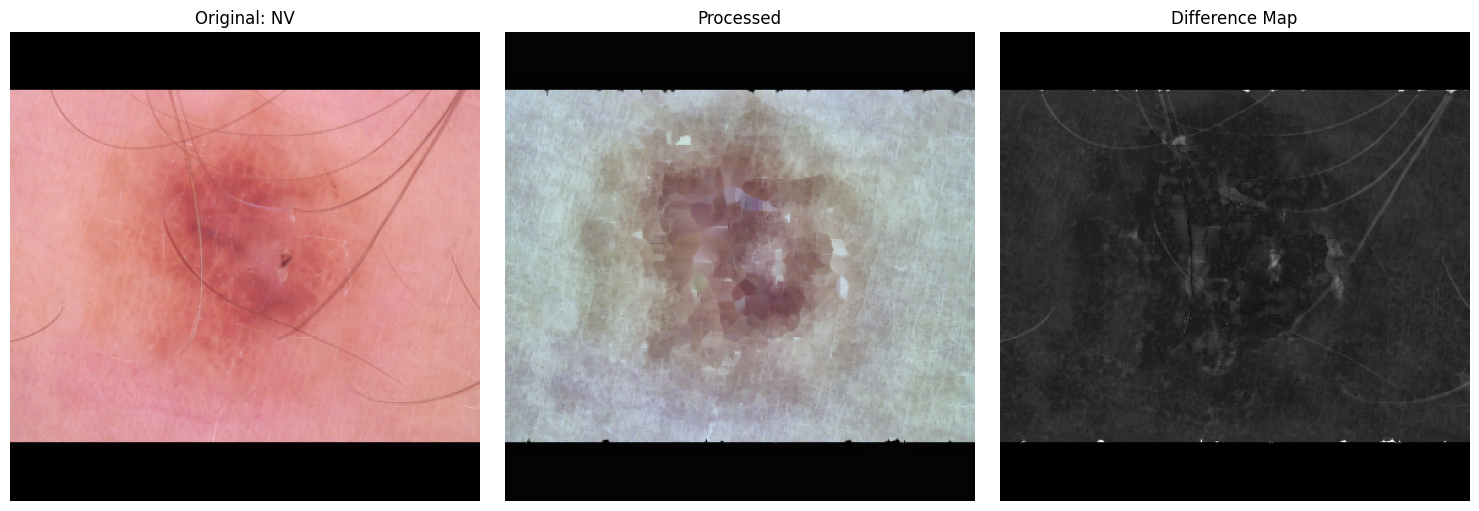

In [24]:
# ---------------------------
# Show one example: original vs processed vs difference map
# ---------------------------
def show_preprocessing_effect(df, sample_index=0, save_path=None):
    row = df.iloc[sample_index]
    bgr = cv2.imread(row["path"])
    if bgr is None:
        raise FileNotFoundError(row["path"])
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    stages = preprocess_with_stages(rgb, size=IMG_SIZE)
    diff = compute_difference_map(stages["original"], stages["final"], size=IMG_SIZE)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(stages["original"])
    axes[0].set_title(f"Original: {row['label']}")
    axes[0].axis("off")

    axes[1].imshow(stages["final"])
    axes[1].set_title("Processed")
    axes[1].axis("off")

    axes[2].imshow(diff, cmap="gray")
    axes[2].set_title("Difference Map")
    axes[2].axis("off")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved preview to:", save_path)

    plt.show()

show_preprocessing_effect(train_df, sample_index=0, save_path="/kaggle/working/preprocessing_effects/example_triplet.png")

In [28]:
# ---------------------------
# Export helper: train / val / test class folders
# ---------------------------
def make_output_name(source_path, label, split):
    source_path = str(source_path)
    stem = Path(source_path).stem
    digest = hashlib.md5(source_path.encode("utf-8")).hexdigest()[:10]
    return f"{split}_{label}_{stem}_{digest}.jpg"

def save_split_dataset(df_split, split_name, out_root: Path, size=384):
    split_dir = out_root / split_name
    records = []

    for cls in EXPECTED_CLASSES:
        (split_dir / cls).mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Saving {split_name}"):
        src_path = Path(row["path"])
        label = str(row["label"])

        bgr = cv2.imread(str(src_path))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        processed = preprocess_image(rgb, size=size)

        out_name = make_output_name(src_path, label, split_name)
        out_path = split_dir / label / out_name

        # cv2.imwrite expects BGR
        cv2.imwrite(str(out_path), cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))

        records.append({
            "split": split_name,
            "label": label,
            "image": out_name,
            "source_path": str(src_path),
            "path": str(out_path),
            "relative_path": str(out_path.relative_to(out_root)),
        })

    return pd.DataFrame(records)

In [ ]:
# ---------------------------
# Build final processed dataset
# ---------------------------
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
OUT_ROOT.mkdir(parents=True, exist_ok=True)

train_processed_df = save_split_dataset(train_df, "train", OUT_ROOT, size=IMG_SIZE)
val_processed_df = save_split_dataset(val_df, "val", OUT_ROOT, size=IMG_SIZE)
test_processed_df = save_split_dataset(test_df, "test", OUT_ROOT, size=IMG_SIZE)

manifest_df = pd.concat([train_processed_df, val_processed_df, test_processed_df], ignore_index=True)
manifest_df = manifest_df.sort_values(["split", "label", "image"]).reset_index(drop=True)

manifest_df.to_csv(OUT_ROOT / "manifest.csv", index=False)
train_processed_df.to_csv(OUT_ROOT / "train.csv", index=False)
val_processed_df.to_csv(OUT_ROOT / "val.csv", index=False)
test_processed_df.to_csv(OUT_ROOT / "test.csv", index=False)

print("Exported rows:", len(manifest_df))
print("Train:", len(train_processed_df))
print("Val  :", len(val_processed_df))
print("Test :", len(test_processed_df))
print()
print("Per-split class counts:")
for split_name, split_df in [("train", train_processed_df), ("val", val_processed_df), ("test", test_processed_df)]:
    print(f"\n[{split_name}]")
    print(split_df["label"].value_counts().reindex(EXPECTED_CLASSES, fill_value=0))

Saving train:   0%|          | 0/20264 [00:00<?, ?it/s]

Saving val:   0%|          | 0/2533 [00:00<?, ?it/s]

In [30]:
# ---------------------------
# Validation helpers
# ---------------------------
def validate_folder_structure(root_dir: Path):
    print("\nFolder structure check:")
    for split in ["train", "val", "test"]:
        missing = []
        for cls in EXPECTED_CLASSES:
            p = root_dir / split / cls
            if not p.exists():
                missing.append(cls)
        print(split, "missing:", missing if missing else "none")

def validate_data_integrity(manifest: pd.DataFrame):
    print("\nData integrity check:")
    missing = manifest["path"].apply(lambda x: not Path(x).exists()).sum()
    print("Missing files:", int(missing))

    dup = manifest.duplicated(subset=["path"]).sum()
    print("Duplicate paths:", int(dup))

    print("Labels:", manifest["label"].unique())
    return {"missing": int(missing), "duplicates": int(dup)}

validate_folder_structure(OUT_ROOT)
_ = validate_data_integrity(manifest_df)


Folder structure check:
train missing: none
val missing: none
test missing: none

Data integrity check:
Missing files: 0
Duplicate paths: 0
Labels: ['AK' 'BCC' 'BKL' 'DF' 'MEL' 'NV' 'SCC' 'VASC']


In [31]:
# ---------------------------
# Dataset summary and zip export
# ---------------------------
summary = {
    "source_dir": str(DATA_DIR),
    "output_dir": str(OUT_ROOT),
    "image_size": IMG_SIZE,
    "seed": SEED,
    "expected_classes": EXPECTED_CLASSES,
    "splits": {
        "train": int(len(train_processed_df)),
        "val": int(len(val_processed_df)),
        "test": int(len(test_processed_df)),
    },
    "total_exported": int(len(manifest_df)),
    "class_counts": manifest_df["label"].value_counts().reindex(EXPECTED_CLASSES, fill_value=0).to_dict(),
}

with open(OUT_ROOT / "dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

zip_path = shutil.make_archive(str(OUT_ROOT), "zip", root_dir=OUT_ROOT)
print("Saved:", OUT_ROOT / "dataset_summary.json")
print("Created ZIP:", zip_path)

Saved: /kaggle/working/SOTA_dataset/dataset_summary.json
Created ZIP: /kaggle/working/SOTA_dataset.zip


In [32]:
# ---------------------------
# Optional W&B artifact logging
# ---------------------------
if wandb is not None:
    try:
        if os.getenv("WANDB_API_KEY"):
            wandb.login(key=os.environ["WANDB_API_KEY"])
        else:
            wandb.login()

        run = wandb.init(
            project=WANDB_PROJECT,
            name=WANDB_RUN_NAME,
            config={
                "seed": SEED,
                "data_dir": str(DATA_DIR),
                "output_dir": str(OUT_ROOT),
                "image_size": IMG_SIZE,
                "classes": EXPECTED_CLASSES,
            },
        )

        artifact = wandb.Artifact(
            name="isic2019-full-fixed-dataset",
            type="dataset",
            description="Processed ISIC2019 dataset with train/val/test folders and CSV manifests",
            metadata={
                "seed": SEED,
                "num_rows": int(len(manifest_df)),
                "train_rows": int(len(train_processed_df)),
                "val_rows": int(len(val_processed_df)),
                "test_rows": int(len(test_processed_df)),
            }
        )
        artifact.add_dir(str(OUT_ROOT))
        run.log_artifact(artifact)
        wandb.finish()
        print("W&B artifact logged.")
    except Exception as e:
        print("W&B skipped:", e)
else:
    print("W&B not installed; skipping artifact logging.")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: Adding directory to artifact (/kaggle/working/SOTA_dataset)... Done. 44.0s


W&B artifact logged.


In [ ]:
# ---------------------------
# Optional Hugging Face upload
# ---------------------------
# Set HF_TOKEN in your environment if you want upload support.
HF_DATASET_REPO_ID = "Abhi830564/isic2019-dataset"

if HfApi is not None:
    try:
        if os.getenv("HF_TOKEN") and hf_login is not None:
            hf_login(token=os.environ["HF_TOKEN"])
        api = HfApi()
        api.create_repo(repo_id=HF_DATASET_REPO_ID, repo_type="dataset", private=False, exist_ok=True)
        api.upload_folder(
            folder_path=str(OUT_ROOT),
            repo_id=HF_DATASET_REPO_ID,
            repo_type="dataset",
            path_in_repo=".",
            commit_message="Upload merged full fixed ISIC2019 dataset pipeline export",
        )
        print("Uploaded to Hugging Face:", HF_DATASET_REPO_ID)
    except Exception as e:
        print("Hugging Face upload skipped:", e)
else:
    print("huggingface_hub not installed; skipping upload.")

In [33]:
print("Pipeline complete.")
print("Final dataset root:", OUT_ROOT)
print("ZIP:", OUT_ROOT.with_suffix(".zip"))

Pipeline complete.
Final dataset root: /kaggle/working/SOTA_dataset
ZIP: /kaggle/working/SOTA_dataset.zip
